In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_PATH = Path("../../results/3_analyze/compress100k.csv")
OVERVIEW_PATH = Path("../../results/1_process/2_aggregate/language_overview.csv")

df = pd.read_csv(RESULTS_PATH)
overview = pd.read_csv(OVERVIEW_PATH, usecols=["used_shortcut", "name"])

df["shortcut"] = df["language"].str.split("_").str[0]
df["script"] = df["language"].str.split("_").str[1]

df = df.merge(overview, left_on="shortcut", right_on="used_shortcut", how="left").drop(columns=["used_shortcut"])
df.rename(columns={"name": "lang_name"}, inplace=True)

print(f"Languages: {len(df)}, Scripts: {df['script'].nunique()}")
df[["language", "lang_name", "script", "unique_chars", "reduction_pct"]].head(10)

Languages: 175, Scripts: 23


,language,lang_name,script,unique_chars,reduction_pct
0,abk_Cyrl,Abkhazian,Cyrl,118,25.51
1,afr_Latn,Afrikaans,Latn,76,22.26
2,als_Latn,Tosk Albanian,Latn,91,22.05
3,amh_Ethi,Amharic,Ethi,424,19.65
4,ara_Arab,Arabic,Arab,113,17.64
5,arg_Latn,Aragonese,Latn,132,24.48
6,arz_Arab,Egyptian Arabic,Arab,188,18.97
7,asm_Beng,Assamese,Beng,149,28.78
8,ast_Latn,Leonese,Latn,98,23.83
9,aze_Latn,Azerbaijani,Latn,247,26.41


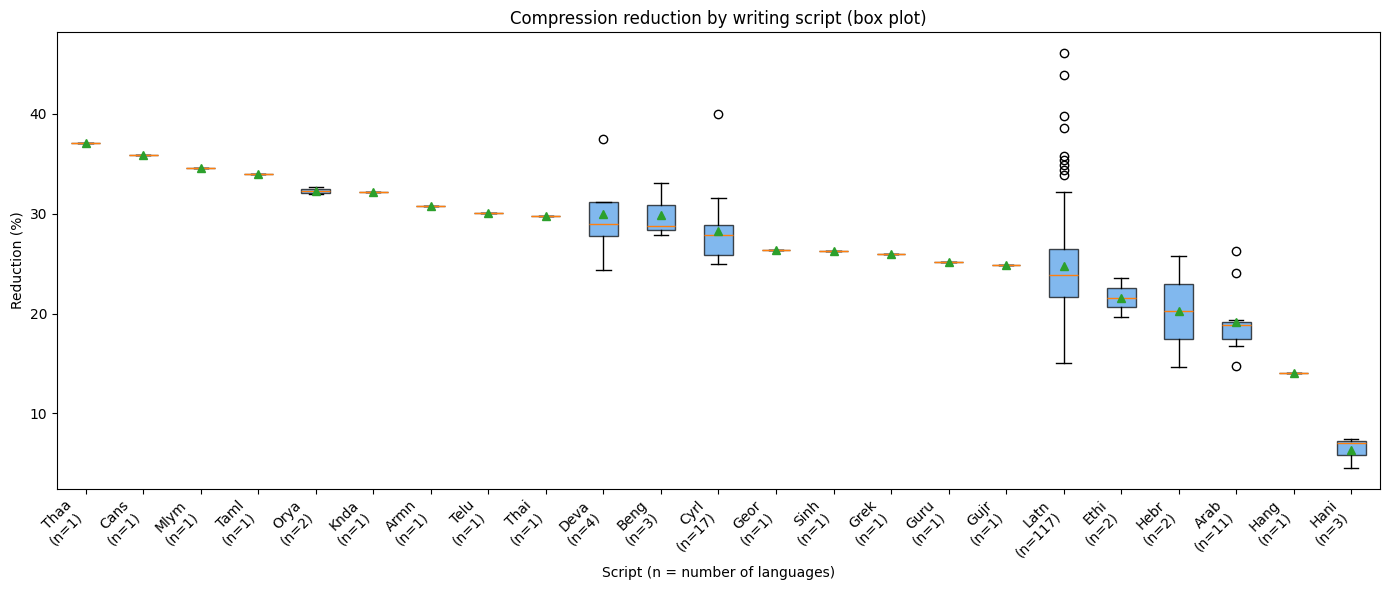

In [2]:
script_order = df.groupby("script")["reduction_pct"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
data_by_script = [df[df["script"] == s]["reduction_pct"].values for s in script_order]
counts = [len(d) for d in data_by_script]
labels = [f"{s}\n(n={c})" for s, c in zip(script_order, counts)]

bp = ax.boxplot(data_by_script, tick_labels=labels, patch_artist=True, showmeans=True)

for patch in bp["boxes"]:
    patch.set_facecolor("#4C9BE8")
    patch.set_alpha(0.7)

ax.set_ylabel("Reduction (%)")
ax.set_title("Compression reduction by writing script (box plot)")
ax.set_xlabel("Script (n = number of languages)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [3]:
stats = df.groupby("script").agg(
    count=("language", "count"),
    mean_chars=("unique_chars", "mean"),
    median_reduction=("reduction_pct", "median"),
    mean_reduction=("reduction_pct", "mean"),
    std_reduction=("reduction_pct", "std"),
    min_reduction=("reduction_pct", "min"),
    max_reduction=("reduction_pct", "max"),
).round(2).sort_values("median_reduction", ascending=False)

stats

,count,mean_chars,median_reduction,mean_reduction,std_reduction,min_reduction,max_reduction
script,,,,,,,
Thaa,1,146.00,37.03,37.03,NaN,37.03,37.03
Cans,1,177.00,35.91,35.91,NaN,35.91,35.91
Mlym,1,147.00,34.62,34.62,NaN,34.62,34.62
Taml,1,164.00,33.94,33.94,NaN,33.94,33.94
Orya,2,134.00,32.30,32.30,0.50,31.94,32.65
Knda,1,139.00,32.12,32.12,NaN,32.12,32.12
Armn,1,158.00,30.75,30.75,NaN,30.75,30.75
Telu,1,126.00,30.08,30.08,NaN,30.08,30.08
Thai,1,104.00,29.76,29.76,NaN,29.76,29.76


In [4]:
selected_scripts = {"Latn", "Cyrl", "Armn", "Geor", "Grek"}
df_sel = df[df["script"].isin(selected_scripts)].copy()
df_sel = df_sel.sort_values("reduction_pct", ascending=False)

print(f"Total: {len(df_sel)} languages\n")
print(f"{'Language':<12} {'Name':<25} {'Script':<6} {'Chars':>5}  {'Reduction':>9}")
print("-" * 62)
for _, row in df_sel.iterrows():
    name = str(row.get('lang_name', ''))[:24]
    print(f"{row['language']:<12} {name:<25} {row['script']:<6} {row['unique_chars']:>5}  {row['reduction_pct']:>8}%")

Total: 137 languages

Language     Name                      Script Chars  Reduction
--------------------------------------------------------------
vol_Latn     Volapük                   Latn      97     46.08%
plt_Latn     Plateau Malagasy          Latn      69     43.88%
che_Cyrl     Chechen                   Cyrl     121     39.95%
min_Latn     Minangkabau               Latn      77     39.78%
war_Latn     Waray (Philippines)       Latn      72     38.61%
nan_Latn     nan                       Latn     161     35.82%
kal_Latn     Kalaallisut               Latn     100     35.36%
wln_Latn     Walloon                   Latn      95     34.92%
ceb_Latn     Cebuano                   Latn     164     34.38%
tuk_Latn     Turkmen                   Latn      92     33.84%
pcm_Latn     Nigerian Pidgin           Latn      48     32.21%
kaz_Cyrl     Kazakh                    Cyrl     114      31.6%
cak_Latn     Cakchiquel                Latn      47     31.37%
ido_Latn     Ido                 

In [5]:
df10 = pd.read_csv("../../results/3_analyze/compress100k.csv")
df100 = pd.read_csv("../../results/3_analyze/compress100k_once.csv")

cmp = df10[["language", "reduction_pct"]].merge(
    df100[["language", "reduction_pct"]], on="language", suffixes=("_10k", "_100k")
)
cmp["diff"] = cmp["reduction_pct_100k"] - cmp["reduction_pct_10k"]
cmp["abs_diff"] = cmp["diff"].abs()

print(f"Languages compared: {len(cmp)}")
print(f"\nDifference (100k - 10k) in reduction_pct:")
print(f"  Mean:   {cmp['diff'].mean():+.2f} pp")
print(f"  Median: {cmp['diff'].median():+.2f} pp")
print(f"  Std:    {cmp['abs_diff'].std():.2f} pp")
print(f"  Max:    {cmp['abs_diff'].max():.2f} pp")
print(f"  >1 pp:  {(cmp['abs_diff'] > 1).sum()} languages")
print(f"  >2 pp:  {(cmp['abs_diff'] > 2).sum()} languages")

# Correlation
corr = cmp["reduction_pct_10k"].corr(cmp["reduction_pct_100k"])
print(f"\nCorrelation (Pearson): {corr:.6f}")

# Scatter plot
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(cmp["reduction_pct_10k"], cmp["reduction_pct_100k"], alpha=0.5, s=20)
ax.plot([40, 85], [40, 85], "r--", linewidth=1, label="y = x")
ax.set_xlabel("Reduction % (10k tokens)")
ax.set_ylabel("Reduction % (100k tokens)")
ax.set_title("10k vs 100k token compression comparison")
ax.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../../results/3_analyze/compress100k_once.csv'

In [ ]:
# Correlation matrix of reduction_pct across multiple result files
base_dir = RESULTS_PATH.parent

file_candidates = {
    "10k": ["compress10k.csv", "compress10k_once.csv"],
    "100k": ["compress100k.csv"],
    "100k_once": ["compress100k_once.csv"],
    "1M": ["compress1M.csv"],
}

resolved_files = {}
for label, candidates in file_candidates.items():
    found = next((base_dir / name for name in candidates if (base_dir / name).exists()), None)
    if found is not None:
        resolved_files[label] = found
    else:
        print(f"[WARN] File for '{label}' not found. Tried: {candidates}")

if len(resolved_files) < 2:
    raise ValueError("Need at least 2 files to compute correlation matrix.")

# Load and merge by language
merged = None
for label, path in resolved_files.items():
    part = pd.read_csv(path, usecols=["language", "reduction_pct"]).rename(
        columns={"reduction_pct": label}
    )
    merged = part if merged is None else merged.merge(part, on="language", how="inner")

corr_matrix = merged.drop(columns=["language"]).corr()

print("Resolved files:")
for k, v in resolved_files.items():
    print(f"  {k:10s} -> {v}")

print(f"\nLanguages in common: {len(merged)}")
corr_matrix

[WARN] File for '1M' not found. Tried: ['compress1M.csv', 'compress1m.csv', 'compress1000k.csv']
Resolved files:
  10k        -> ..\..\results\3_analyze\compress10k.csv
  100k       -> ..\..\results\3_analyze\compress100k.csv
  100k_once  -> ..\..\results\3_analyze\compress100k_once.csv

Languages in common: 173


,10k,100k,100k_once
10k,1.000000,0.629502,0.628394
100k,0.629502,1.000000,0.999884
100k_once,0.628394,0.999884,1.000000
